In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit

# Fig 5

This code use the following csv data created with the corresponging C++ code:
- Pareto front/finalpop_n10000_time300_less.csv --- Pareto front/extinction_rate.cpp --- Fig5B, Fig5C
- Pareto front/ext_rate_n10000_time300_less.csv --- Pareto front/extinction_rate.cpp --- Fig5A, Fig5C

Both csv files must be reconstructed using the following command:

    > cat finalpop_part_* > finalpop_n10000_time300_less.csv
    > cat ext_rate_part_* > ext_rate_n10000_time300_less.csv

/var/folders/pn/ln92hbl56jj2m2mzfrm1cl4c0000gn/T/ipykernel_9724/2131717595.py:159: RuntimeWarning: invalid value encountered in power
  return (alpha - x**p)**(1/q)


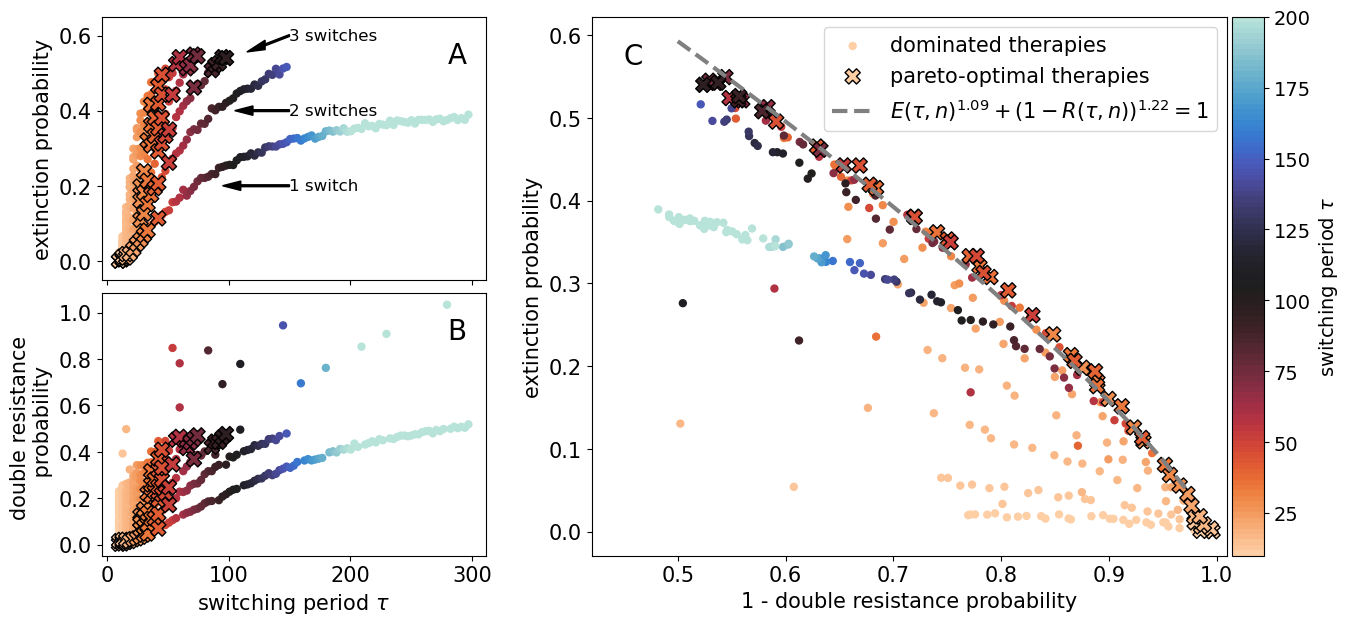

In [4]:
df = pd.read_csv('Pareto front/finalpop_n10000_time300_less.csv')


dfE = pd.read_csv('Pareto front/ext_rate_n10000_time300_less.csv')
dfE['Theoretical Time'] = dfE['Rounds']*dfE['SeasonLength']+50
dfE['Dead'] = dfE['FinalTime'] < dfE['Theoretical Time']
dfE = dfE[dfE['Dead'] == True]
dfE = dfE.groupby(['SeasonLength','Rounds']).count().reset_index()
dfE['pext'] = dfE['FinalTime'] / 10000
dfE = dfE[['SeasonLength','Rounds','pext','FinalTime']].rename(columns={'FinalTime':'count'})


dfpop100 = df[df['final']==0].copy()
dfpop100.loc[:,'x3>=1'] = dfpop100['x3'] >= 1
dfpop100 = dfpop100.groupby(['SeasonLength','x3>=1','Rounds']).count().reset_index()
dfpop100 = dfpop100[dfpop100['x3>=1']==True]
dfpop100 = dfpop100.merge(dfE, on=['SeasonLength','Rounds'])
dfpop100['1 - prob(x3)'] = 1 - dfpop100['Time'] / (10000 - dfpop100['count'])
dfpop100 = dfpop100[['SeasonLength','Rounds','1 - prob(x3)']]

dfpareto = dfpop100.merge(dfE, on=['SeasonLength','Rounds'])




dfTOP = dfpareto.copy()

new_cols = {}
points = []  # top points

# --- Calculate top 10 points for the objetive function alpha*(1-doble resistance prob) + beta*extinction prob ---
for alpha in np.linspace(1, 5, 10):
    for beta in np.linspace(1, 5, 10):
        colname = f"{alpha:.2f}x+{beta:.2f}y"
        new_col = alpha * dfTOP['1 - prob(x3)'] + beta * dfTOP['pext']
        new_cols[colname] = new_col

        top_idx = new_col.nlargest(10).index
        top = dfTOP.loc[top_idx, ['SeasonLength', 'Rounds', '1 - prob(x3)', 'pext']].copy()
        top['alpha'] = alpha
        top['beta'] = beta
        points.append(top)

# add clumns
dfTOP = pd.concat([dfTOP, pd.DataFrame(new_cols)], axis=1)
points_df = pd.concat(points, ignore_index=True)[['SeasonLength','Rounds']]
points_df['IN'] = 1

points_df2 = points_df.groupby(['SeasonLength','Rounds']).count().reset_index()

dfm = dfTOP.merge(points_df2, on=['SeasonLength','Rounds'], how='outer')
dfm['IN'] = dfm['IN'].replace({np.nan:0})

#set colormaps
orden = sorted(dfm['SeasonLength'].unique(), reverse=True)
colors = sns.color_palette('icefire_r',len(orden))
colorsR = sns.color_palette('icefire',len(orden))
special_palette=dict(zip(orden,colorsR))
cmap = ListedColormap(colors)


fig = plt.figure(figsize=(15, 7))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1, 1.75],   
    height_ratios=[1, 1],
    wspace=0.20,  
    hspace=0.05,
    figure=fig
)

axes = [
    fig.add_subplot(gs[0, 0]),   
    fig.add_subplot(gs[1, 0]),   
    fig.add_subplot(gs[:, 1])   
]

# --- SUBPLOT 1: switching period (SeasonLength) vs extinction probability ---
sc1 = axes[0].scatter(
    dfm.loc[dfm['IN']==0,'SeasonLength'], dfm.loc[dfm['IN']==0,'pext'],
    c=dfm.loc[dfm['IN']==0,'SeasonLength'], cmap=cmap,
    vmax=200, marker='.', s=100, label='dominated therapies'
)
axes[0].scatter(
    dfm[dfm['IN']!=0]['SeasonLength'], dfm[dfm['IN']!=0]['pext'],
    c=dfm[dfm['IN']!=0]['SeasonLength'], cmap=cmap, vmax=200,
    marker='X', s=120, ec='black', linewidth=1, label='pareto-optimal therapies'
)


axes[0].text(150,0.2,'1 switch',fontsize=12, va='center')
axes[0].arrow(150, 0.2, -40, 0, width=0.005, color='black', head_width=0.025, ec='black',head_length=15)
axes[0].text(150,0.4,'2 switches',fontsize=12, va='center')
axes[0].arrow(150, 0.4, -30, 0, width=0.005, color='black', head_width=0.025, ec='black',head_length=15)
axes[0].text(150,0.6,'3 switches',fontsize=12, va='center')
axes[0].arrow(150, 0.6, -20, -0.025, width=0.005, color='black', head_width=0.025, ec='black',head_length=15)



axes[0].set_ylabel('extinction probability', fontsize=15)
axes[0].tick_params(labelsize=15)
axes[0].tick_params(labelbottom=False) 
axes[0].set_ylim(-0.05,0.65)

# --- SUBPLOT 2: switching period (SeasonLength) vs double resistance probability ---
sc2 = axes[1].scatter(
    dfm[dfm['IN']==0]['SeasonLength'], 1 - dfm[dfm['IN']==0]['1 - prob(x3)'],
    c=dfm[dfm['IN']==0]['SeasonLength'], cmap=cmap,
    vmax=200, marker='.', s=100, label='dominated therapies'
)
axes[1].scatter(
    dfm[dfm['IN']!=0]['SeasonLength'], 1 - dfm[dfm['IN']!=0]['1 - prob(x3)'],
    c=dfm[dfm['IN']!=0]['SeasonLength'], cmap=cmap, vmax=200,
    marker='X', s=120, ec='black', linewidth=1, label='pareto-optimal therapies'
)

axes[1].set_ylabel('double resistance \n probability', fontsize=15)
axes[1].set_xlabel('switching period '+r'$\tau$', fontsize=15)
axes[1].tick_params(labelsize=15)

# --- SUBPLOT 3: Pareto front ---
sc3 = axes[2].scatter(
    dfm[dfm['IN']==0]['1 - prob(x3)'], dfm[dfm['IN']==0]['pext'],
    c=dfm[dfm['IN']==0]['SeasonLength'], cmap=cmap,
    vmax=200, marker='.', s=100, label='dominated therapies'
)
axes[2].scatter(
    dfm[dfm['IN']!=0]['1 - prob(x3)'], dfm[dfm['IN']!=0]['pext'],
    c=dfm[dfm['IN']!=0]['SeasonLength'], cmap=cmap, vmax=200,
    marker='X', s=120, ec='black', linewidth=1, label='pareto-optimal therapies'
)

divider = make_axes_locatable(axes[2])
cax = divider.append_axes("right", size="5%", pad=0.05) 
cbar = fig.colorbar(sc3, cax=cax)
cbar.set_label('switching period '+r'$\tau$', fontsize=14)
cbar.ax.tick_params(labelsize=14)

axes[2].set_xlabel('1 - double resistance probability', fontsize=15)
axes[2].set_ylabel('extinction probability', fontsize=15)
axes[2].tick_params(labelsize=15)
axes[2].set_xlim(0.42, 1.01)


# === letters A, B, C ===
letters = ['A', 'B']
for ax, letter in zip(axes, letters):
    ax.text(
        0.9, 0.8, letter,  
        transform=ax.transAxes,
        fontsize=20,
        va='bottom', ha='left',
    )
axes[2].text(0.05, 0.9, 'C', transform=axes[2].transAxes,fontsize=20, va='bottom', ha='left')


def paretofit(x,p,q,alpha):
    return (alpha - x**p)**(1/q)

x = dfm[dfm['IN']!=0]['1 - prob(x3)'].values
y = dfm[dfm['IN']!=0]['pext'].values

popt, pcov = curve_fit(paretofit, x, y)

xfit = np.linspace(0.5,1,20)
a, b = str(round(popt[0], 2)), str(round(popt[1], 2))

axes[2].plot(
    xfit,
    paretofit(xfit, popt[0], popt[1], popt[2]),
    label=fr'$E(\tau,n)^{{{a}}} + (1-R(\tau,n))^{{{b}}} = 1$',
    color='gray',
    linestyle='--', linewidth=3,
)
    
axes[2].legend(fontsize=15)

plt.savefig('Fig5.png',dpi=300)
plt.show()

**Optimal therapy**
(*A*) Extinction probability as a function of the switching period.
(*B*) Probability of double resistant mutants at the end of the threatment, conditioned on the population not being extinct.
(*C*) Pareto front of optimal switching therapies. The crosses indicate therapies that belong to the Pareto front, while the circles show dominated (suboptimal) therapies. The grey dashed line indicates the empirical fit. The probability that a therapy is in the Pareto front is maximized for $\tau \approx 40$. Simulated therapy trajectories were generated with different switching periods ($\tau$) and numbers of treatment rounds ($n$), constrained such that $\tau \cdot n + 50 < 350$, number of trajectories $=10000$, $k=0.5$, $k_{CS}=0.05$.

# Fig S10

This code use the following csv data created with the corresponging C++ code:
- Pareto front/finalpop_n10000_time300_less.csv --- Pareto front/extinction_rate.cpp --- FigS10A, FigS10B
- Pareto front/ext_rate_n10000_time300_less.csv --- Pareto front/extinction_rate.cpp --- FigS10A, FigS10B

Both csv files must be reconstructed using the following command:

    > cat finalpop_part_* > finalpop_n10000_time300_less.csv
    > cat ext_rate_part_* > ext_rate_n10000_time300_less.csv

/var/folders/pn/ln92hbl56jj2m2mzfrm1cl4c0000gn/T/ipykernel_9724/375371369.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('icefire', num_rounds).colors


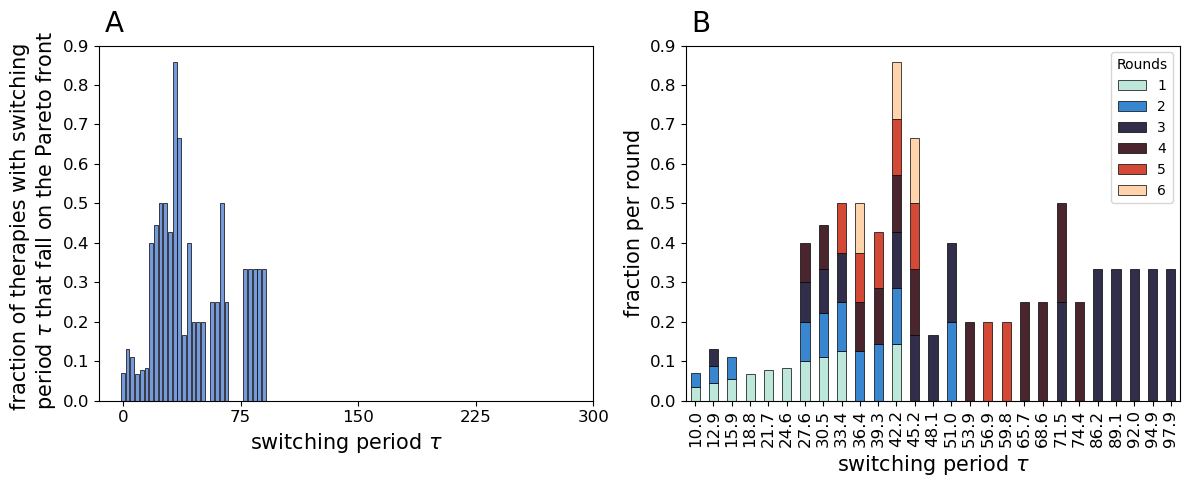

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# S10-A -------------------------------------------
dfmg = dfm.copy()
dfmg['IN'] = dfmg['IN'] != 0
dfmg = dfmg.groupby(['SeasonLength','IN']).count().reset_index()[['SeasonLength','Rounds','IN']]

dfsum = dfmg.groupby('SeasonLength').sum().reset_index()[['SeasonLength','Rounds']]

dfmg = dfmg.merge(dfsum, on='SeasonLength')
dfmg['percentaje'] = dfmg['Rounds_x'] / dfmg['Rounds_y']
dfmg = dfmg[dfmg['IN'] == False]
dfmg['hist'] = 1 - dfmg['percentaje']

sns.barplot(
    data=dfmg,
    x='SeasonLength', y='hist',
    color='cornflowerblue',
    ec='black', linewidth=0.5,
    legend=False,
    ax=axes[0]
)

axes[0].set_xticks(np.linspace(0,100,5))
axes[0].set_xticklabels(np.linspace(0,300,5).astype(int))
axes[0].set_xlim(-5,100)
axes[0].set_xlabel('switching period '+r'$\tau$', fontsize=15)
axes[0].set_ylabel('fraction of therapies with switching \n period '+r'$\tau$'+' that fall on the Pareto front', fontsize=15)
axes[0].tick_params(labelsize=12)


# S10-B -------------------------------------------
dfm2 = dfm[dfm['IN']!=0][['SeasonLength','Rounds']].merge(dfmg[['SeasonLength','Rounds_y']], on='SeasonLength')
dfm2['percentaje'] = 1 / dfm2['Rounds_y']

df_pivot = dfm2.pivot(index='SeasonLength', columns='Rounds', values='percentaje').fillna(0)

num_rounds = len(df_pivot.columns)
colors = cm.get_cmap('icefire', num_rounds).colors  

df_pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=colors,         
    edgecolor='black',
    linewidth=0.5
)

axes[1].set_xlabel('switching period '+r'$\tau$', fontsize=15)
axes[1].set_ylabel('fraction per round', fontsize=15)
axes[1].tick_params(labelsize=12)
axes[1].legend(title='Rounds', loc='upper right')

xticks = axes[1].get_xticks()
labels = [float(l.get_text()) for l in axes[1].get_xticklabels()]
axes[1].set_xticklabels([f'{l:.1f}' for l in labels])

# letters
letters = ['A', 'B']
for ax, letter in zip(axes, letters):
    ax.text(
        0.01, 1.1, letter,  
        transform=ax.transAxes,
        fontsize=20,
        va='top',
    )
plt.tight_layout()
plt.savefig('FigS10.png',dpi=300)
plt.show()

**Optimal window.** Simulated therapy trajectories were generated with different switching periods ($\tau$) and numbers of treatment rounds ($n$), constrained such that $\tau \cdot n + 50 < 350$.
(*A*) Percentage of therapies with a given switching period $\tau$ that lie on the Pareto front.
(*B*) Distribution of these percentages across the different numbers of treatment rounds.
We observe that certain switching periods consistently fall on the Pareto front regardless of the number of rounds $\tau \approx 40$, while others are optimal only for one $\tau \approx 20$ or three $\tau \approx 90$ switching events.
Number of trajectories $=10000$.